In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import zipfile

# Drive paths
drive_base = "/content/drive/MyDrive/Eyepacs"
zip_images = os.path.join(drive_base, "fundus_images.zip")
drive_labels = os.path.join(drive_base, "psuedolabels")

# Local Colab paths
local_base = "/content/fundus_dataset"
local_images = os.path.join(local_base, "fundus_images")
local_disc = os.path.join(local_base, "optic_disc")
local_cup = os.path.join(local_base, "optic_cup")

os.makedirs(local_base, exist_ok=True)


In [ ]:
if not os.path.exists(local_images):
    with zipfile.ZipFile(zip_images, 'r') as zip_ref:
        zip_ref.extractall(local_base)
    print("✅ Fundus images extracted to local storage")


✅ Fundus images extracted to local storage


In [ ]:
if not os.path.exists(local_disc):
    shutil.copytree(
        os.path.join(drive_labels, "optic_disc"),
        local_disc
    )
    print("✅ Optic disc copied")

if not os.path.exists(local_cup):
    shutil.copytree(
        os.path.join(drive_labels, "optic_cup"),
        local_cup
    )
    print("✅ Optic cup copied")


✅ Optic disc copied
✅ Optic cup copied


In [ ]:
print("Images:", len(os.listdir(local_images)))
print("Disc masks:", len(os.listdir(local_disc)))
print("Cup masks:", len(os.listdir(local_cup)))


Images: 9553
Disc masks: 9538
Cup masks: 9538


In [ ]:

!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


In [ ]:
NUM_WORKERS   = 2
BATCH_SIZE    = 8
EPOCHS        = 20

In [ ]:
# ===============================
# 0. IMPORTS
# ===============================
import os, shutil, zipfile, random
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp  # <--- WE WILL USE THIS NOW

In [ ]:
# ===============================
# 1. SEED & DEVICE
# ===============================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
# Hyperparameters
IMG_SIZE      = 512
BATCH_SIZE    = 8
EPOCHS        = 20      # Increased slightly as pretrained models can handle it
NUM_WORKERS   = 2
LR            = 1e-4    # Lower LR is better for pretrained backbones
WEIGHT_DECAY  = 1e-5
VAL_RATIO     = 0.2


In [ ]:
local_base   = "/content/fundus_dataset"

local_images = os.path.join(local_base, "fundus_images")
local_disc   = os.path.join(local_base, "optic_disc")
local_cup    = os.path.join(local_base, "optic_cup")

In [ ]:
# ===============================
# 3. ROBUST GLACUOMA DATASET
# ===============================
class GlaucomaDataset(Dataset):
    def __init__(self, img_dir, disc_dir, cup_dir, transform=None):
        self.img_dir = img_dir
        self.disc_dir = disc_dir
        self.cup_dir  = cup_dir
        self.transform = transform

        # ---- List all images ----
        all_images = sorted([
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        # ---- List all masks ----
        disc_files = set(os.listdir(disc_dir))
        cup_files  = set(os.listdir(cup_dir))

        # ---- Filter only images with matching disc & cup masks ----
        self.images = []
        for img in all_images:
            base = os.path.splitext(img)[0]  # numeric ID
            # Construct expected mask filenames
            disc_mask_name = f"OD_{base}.jpg"
            cup_mask_name  = f"OC_{base}.jpg"

            if disc_mask_name in disc_files and cup_mask_name in cup_files:
                self.images.append(img)

        print(f"[Dataset] Loaded {len(self.images)} valid samples")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        # ---- Load Image ----
        image_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Corrupted or missing image: {img_name}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ---- Load Masks ----
        base = os.path.splitext(img_name)[0]
        disc_mask_path = os.path.join(self.disc_dir, f"OD_{base}.jpg")
        cup_mask_path  = os.path.join(self.cup_dir,  f"OC_{base}.jpg")

        disc_mask = cv2.imread(disc_mask_path, cv2.IMREAD_GRAYSCALE)
        cup_mask  = cv2.imread(cup_mask_path,  cv2.IMREAD_GRAYSCALE)

        if disc_mask is None or cup_mask is None:
            raise FileNotFoundError(f"Missing mask for {img_name}")

        # ---- Merge masks (0=background, 1=disc, 2=cup) ----
        mask = np.zeros(disc_mask.shape, dtype=np.uint8)
        mask[disc_mask > 127] = 1
        mask[cup_mask  > 127] = 2

        # ---- Apply Transformations ----
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        return image, torch.as_tensor(mask).long()


In [ ]:
# ===============================
# 4. DATA AUGMENTATION (Fixed)
# ===============================
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    # REPLACEMENT: ShiftScaleRotate -> Affine
    # scale=(0.9, 1.1) matches scale_limit=0.1
    # translate_percent match shift_limit=0.0625
    # rotate=(-15, 15) matches rotate_limit=15
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.0625, 0.0625),
        rotate=(-15, 15),
        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [ ]:
# ===============================
# 5. NEW MODEL: Pretrained U-Net
# ===============================
# Replaces the custom 'class UNet'.
# ResNet34 is powerful enough for medical features but light enough for Colab.
model = smp.Unet(
    encoder_name="resnet34",        # Choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # Use ImageNet pre-trained weights
    in_channels=3,                  # Input channels (RGB)
    classes=3,                      # Background, Disc, Cup
    activation=None                 # Return logits (required for Loss function)
).to(DEVICE)


In [ ]:

# ===============================
# 6. IMPROVED LOSS FUNCTION
# ===============================
class RefinedHybridLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Focal Loss: Focuses on hard pixels (boundaries)
        self.focal = smp.losses.FocalLoss(mode="multiclass", ignore_index=None)

        # Tversky Loss: Better for class imbalance (Small Cup)
        self.tversky = smp.losses.TverskyLoss(
            mode="multiclass",
            classes=[1, 2],
            log_loss=True,
            from_logits=True,
            alpha=0.3, beta=0.7 # Penalize False Negatives more
        )

    def forward(self, preds, targets):
        # Combined Loss
        return 0.5 * self.focal(preds, targets) + 0.5 * self.tversky(preds, targets)

criterion = RefinedHybridLoss()

In [ ]:
print(os.listdir(local_images)[:5])
print(os.listdir(local_disc)[:5])
print(os.listdir(local_cup)[:5])

['09518.jpg', '05256.jpg', '02404.jpg', '06227.jpg', '08405.jpg']
['OD_01562.jpg', 'OD_02300.jpg', 'OD_08759.jpg', 'OD_01356.jpg', 'OD_00913.jpg']
['OC_07410.jpg', 'OC_02410.jpg', 'OC_08542.jpg', 'OC_09393.jpg', 'OC_09477.jpg']


In [ ]:
# Example
dataset = GlaucomaDataset(local_images, local_disc, local_cup, transform=train_transform)

# Check dataset length
print(f"Number of training samples: {len(dataset)}")

val_size  = int(len(dataset) * VAL_RATIO)
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)


[Dataset] Loaded 9537 valid samples
Number of training samples: 9537


In [ ]:
# ===============================
# 8. OPTIMIZER & SCHEDULER (Fixed)
# ===============================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Scheduler without 'verbose' (it was removed in new PyTorch versions)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

In [ ]:
# ===============================
# 9. UTILS (Dice Score)
# ===============================
def dice_score(pred, target, cls):
    pred_bin   = (pred == cls).astype(np.uint8)
    target_bin = (target == cls).astype(np.uint8)
    intersection = np.sum(pred_bin * target_bin)
    union = np.sum(pred_bin) + np.sum(target_bin)
    if union == 0: return 1.0
    return (2.0 * intersection) / union

In [ ]:
# ===============================
# 10. TRAINING LOOP (Updated)
# ===============================
def validate(model, loader, device):
    model.eval()
    val_loss = 0.0
    dice_disc, dice_cup = [], []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            masks = masks.cpu().numpy()

            for i in range(preds.shape[0]):
                dice_disc.append(dice_score(preds[i], masks[i], cls=1))
                dice_cup.append(dice_score(preds[i], masks[i], cls=2))

    return val_loss/len(loader), np.mean(dice_disc), np.mean(dice_cup)

In [ ]:
# Initialize best loss to infinity so the first run always saves
best_val_loss = float('inf')

history = {"train_loss": [], "val_loss": [], "dice_disc": [], "dice_cup": []}

print("Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss, dice_d, dice_c = validate(model, val_loader, DEVICE)

    # Step the scheduler
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["dice_disc"].append(dice_d)
    history["dice_cup"].append(dice_c)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Dice(D): {dice_d:.3f} | "
          f"Dice(C): {dice_c:.3f}")

    # --- NEW: SAVE BEST MODEL ---
    # Only save if the current validation loss is lower than the best we've seen
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_path = os.path.join(drive_base, "unet_resnet34_BEST.pth")
        torch.save(model.state_dict(), save_path)
        print(f">>> New Best Model Saved (Val Loss: {val_loss:.4f})")

    # Optional: Keep saving periodic checkpoints if you want
    if (epoch + 1) % 5 == 0:
         torch.save(model.state_dict(), os.path.join(drive_base, f"unet_resnet34_epoch{epoch+1}.pth"))

# Save the final model just in case
torch.save(model.state_dict(), os.path.join(drive_base, "unet_resnet34_final.pth"))
print("Training Complete.")

Starting Training...
Epoch [1/20] | Train Loss: 0.5402 | Val Loss: 0.1734 | Dice(D): 0.747 | Dice(C): 0.726
>>> New Best Model Saved (Val Loss: 0.1734)
Epoch [2/20] | Train Loss: 0.1459 | Val Loss: 0.1444 | Dice(D): 0.782 | Dice(C): 0.756
>>> New Best Model Saved (Val Loss: 0.1444)
Epoch [3/20] | Train Loss: 0.1280 | Val Loss: 0.1486 | Dice(D): 0.779 | Dice(C): 0.749
Epoch [4/20] | Train Loss: 0.1176 | Val Loss: 0.1254 | Dice(D): 0.796 | Dice(C): 0.776
>>> New Best Model Saved (Val Loss: 0.1254)
Epoch [5/20] | Train Loss: 0.1095 | Val Loss: 0.1370 | Dice(D): 0.776 | Dice(C): 0.756
Epoch [6/20] | Train Loss: 0.1018 | Val Loss: 0.1176 | Dice(D): 0.804 | Dice(C): 0.787
>>> New Best Model Saved (Val Loss: 0.1176)
Epoch [7/20] | Train Loss: 0.0965 | Val Loss: 0.1136 | Dice(D): 0.820 | Dice(C): 0.799
>>> New Best Model Saved (Val Loss: 0.1136)
Epoch [8/20] | Train Loss: 0.0925 | Val Loss: 0.1154 | Dice(D): 0.805 | Dice(C): 0.789
Epoch [9/20] | Train Loss: 0.0872 | Val Loss: 0.1106 | Dice(D):

In [ ]:
torch.save(model.state_dict(), "unet_resnet34.pth")

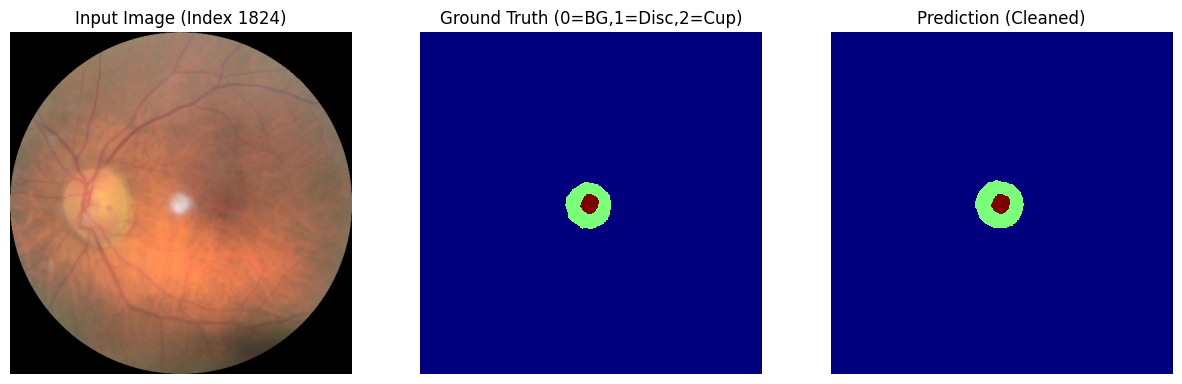

In [ ]:
# ===============================
# 10. VISUALIZATION CHECK (With Post-Processing)
# ===============================
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. Define the Cleaning Function ---
def clean_segmentation(mask_array):
    """
    Keeps only the largest connected component (main Optic Disc + Cup).
    Removes small floating noise specs in the background.
    """
    binary_mask = (mask_array > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, connectivity=8)

    if num_labels > 2:
        # skip background (0)
        areas = stats[1:, 4]
        max_label = np.argmax(areas) + 1

        clean_mask = np.zeros_like(mask_array)
        clean_mask[labels == max_label] = mask_array[labels == max_label]
        return clean_mask

    return mask_array

# --- 2. Visualization Function ---
def visualize_prediction(model, dataset, idx=None):
    model.eval()

    if idx is None:
        idx = random.randint(0, len(dataset)-1)

    # 1. Get data
    image, mask = dataset[idx]

    # Add batch dimension
    image_tensor = image.unsqueeze(0).to(DEVICE)

    # 2. Predict
    with torch.no_grad():
        output = model(image_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    # 3. Clean prediction
    pred_mask = clean_segmentation(pred_mask)

    # 4. Prepare image for plotting
    img_np = image.permute(1, 2, 0).cpu().numpy()
    # Undo normalization
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # 5. Convert ground truth mask to numpy
    mask_np = mask.cpu().numpy()

    # 6. Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title(f"Input Image (Index {idx})")
    axes[0].axis("off")

    axes[1].imshow(mask_np, cmap='jet', interpolation='nearest')
    axes[1].set_title("Ground Truth (0=BG,1=Disc,2=Cup)")
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap='jet', interpolation='nearest')
    axes[2].set_title("Prediction (Cleaned)")
    axes[2].axis("off")

    plt.show()

# --- 3. Run visualization on a random image ---
visualize_prediction(model, dataset)


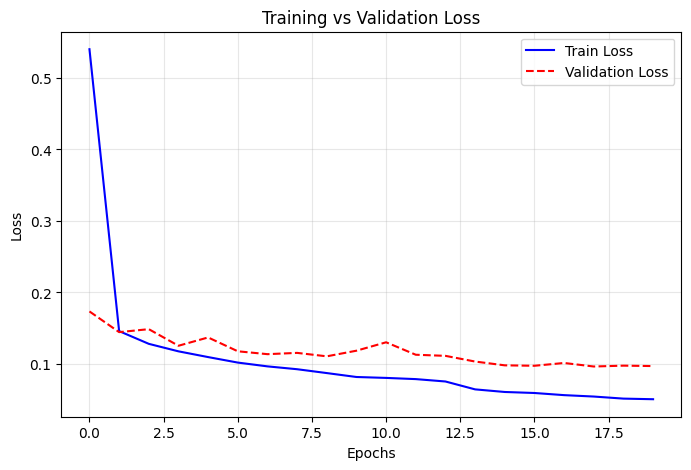

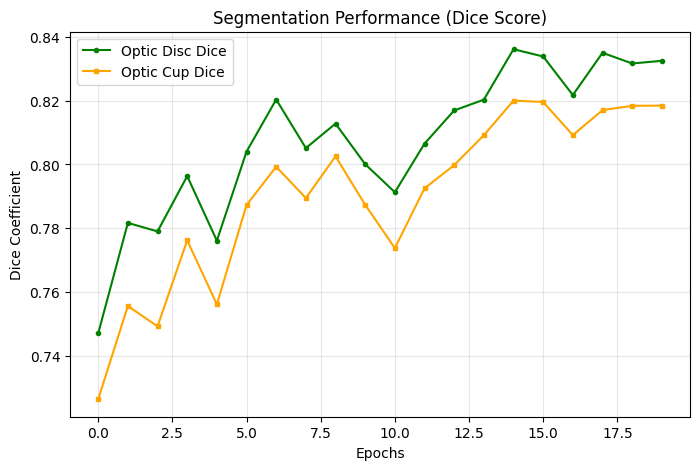

In [ ]:
# ==========================================
# PLOT TRAINING HISTORY
# ==========================================
import matplotlib.pyplot as plt

# 1. Plot Loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", color='blue', linestyle='-')
plt.plot(history["val_loss"], label="Validation Loss", color='red', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/Eyepacs/figure_training_loss.png', dpi=300)
plt.show()

# 2. Plot Dice Scores
plt.figure(figsize=(8, 5))
plt.plot(history["dice_disc"], label="Optic Disc Dice", color='green', marker='o', markersize=3)
plt.plot(history["dice_cup"], label="Optic Cup Dice", color='orange', marker='s', markersize=3)
plt.xlabel("Epochs")
plt.ylabel("Dice Coefficient")
plt.title("Segmentation Performance (Dice Score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('/content/drive/MyDrive/Eyepacs/figure_dice_score.png', dpi=300)
plt.show()

In [ ]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

def plot_3d_loss_landscape_schematic(history):
    # 1. Prepare Trajectory Data
    epochs = np.array(list(range(1, len(history["train_loss"]) + 1)))
    val_loss = np.array(history["val_loss"])
    train_loss = np.array(history["train_loss"])
    dice = np.array(history["dice_cup"])

    # 2. Generate a "Schematic" Surface (The Mountain)
    # We create a grid around your trajectory to simulate a 'valley'
    # This is for visualization purposes to show convergence.

    # Create a grid of points
    x_grid = np.linspace(min(epochs), max(epochs), 50)
    y_grid = np.linspace(min(val_loss) * 0.8, max(val_loss) * 1.2, 50)
    X, Y = np.meshgrid(x_grid, y_grid)

    # Create a synthetic "Valley" function:
    # Z (Loss) increases as you get further from the ideal Epoch/Loss path
    # This is a mathematical trick to make a pretty surface that respects your data bounds
    Z_approx = np.zeros_like(X)

    # Simple interpolation of your actual train loss to define the "floor" of the valley
    fitted_loss = np.interp(X, epochs, train_loss)

    # Add "walls" to the valley (Loss goes up as validation error deviates)
    # This creates the U-shape curve
    Z = fitted_loss + 0.5 * (Y - np.interp(X, epochs, val_loss))**2

    # 3. Create the Plot
    fig = go.Figure()

    # --- A. The Surface (The Mountain) ---
    fig.add_trace(go.Surface(
        z=Z, x=X, y=Y,
        colorscale='Blues',
        opacity=0.6,
        showscale=False,
        name='Loss Landscape (Schematic)'
    ))

    # --- B. The Trajectory (Your Actual Model) ---
    fig.add_trace(go.Scatter3d(
        x=epochs,
        y=val_loss,
        z=train_loss,
        mode='lines+markers',
        marker=dict(
            size=6,
            color=dice,
            colorscale='Hot', # Fire color for the path
            showscale=True,
            colorbar=dict(title="Dice Score", x=0.9)
        ),
        line=dict(color='red', width=4),
        name='Your Model Path'
    ))

    # --- C. Layout ---
    fig.update_layout(
        title="3D Optimization Landscape (Schematic Visualization)",
        scene=dict(
            xaxis_title='Epochs (Time)',
            yaxis_title='Validation Loss',
            zaxis_title='Training Loss',
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.2))
        ),
        height=800,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

# Run it
plot_3d_loss_landscape_schematic(history)

In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# ===============================
# 1. CONFIGURATION & PATHS
# ===============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BASE_PATH2 = "/content/drive/MyDrive/Eyepacs"
MODEL_PATH    = os.path.join(BASE_PATH2, "unet_resnet34_final.pth")


In [ ]:

# ===============================
# 2. CDR CALCULATION FUNCTION
# ===============================
def calculate_vertical_cdr(mask_arr):
    """
    Calculates Vertical Cup-to-Disc Ratio (CDR).
    mask_arr: 2D numpy array with 0=BG, 1=Disc, 2=Cup
    """
    # Extract Disc and Cup pixels
    disc_pixels = np.argwhere(mask_arr == 1)
    cup_pixels  = np.argwhere(mask_arr == 2)

    # Check if we actually found pixels (safety check)
    if len(disc_pixels) == 0:
        return 0.0, 0.0, 0.0  # Model failed to find Disc

    # Get Vertical Heights (Max Row - Min Row)
    # Note: In a combined mask, Cup (2) is *inside* Disc.
    # Usually Disc mask includes the Cup area logically,
    # but in your pixel values 2 overwrites 1.
    # So True Disc Area = (Pixels==1) + (Pixels==2)

    # 1. Calculate Disc Height (Include Cup pixels as part of Disc)
    all_disc_pixels = np.argwhere(mask_arr > 0)
    disc_min_y, disc_max_y = all_disc_pixels[:, 0].min(), all_disc_pixels[:, 0].max()
    disc_height = disc_max_y - disc_min_y

    # 2. Calculate Cup Height
    if len(cup_pixels) == 0:
        cup_height = 0
    else:
        cup_min_y, cup_max_y = cup_pixels[:, 0].min(), cup_pixels[:, 0].max()
        cup_height = cup_max_y - cup_min_y

    # 3. Calculate CDR
    if disc_height == 0: return 0.0 # Avoid division by zero
    cdr = cup_height / disc_height

    return cdr, cup_height, disc_height

In [ ]:

# ===============================
# 3. LOAD THE TRAINED MODEL
# ===============================
print(f"Loading model from: {MODEL_PATH}")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # No need to download weights, we are loading ours
    in_channels=3,
    classes=3,
    activation=None
).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Model loaded successfully!")

Loading model from: /content/drive/MyDrive/Eyepacs/unet_resnet34_final.pth
Model loaded successfully!


In [ ]:
# ===============================
# 4. PREPROCESSING (Must match Training!)
# ===============================
test_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])


In [ ]:
!cp -r "/content/drive/MyDrive/REFUGE2_Processed" "/content/processed"

In [ ]:

PROCESSED_BASE = "/content/processed"

TEST_IMG_DIR  = os.path.join(PROCESSED_BASE, "images")
TEST_CUP_DIR  = os.path.join(PROCESSED_BASE, "cup_masks")
TEST_DISC_DIR = os.path.join(PROCESSED_BASE, "disc_masks")

# Ensure these constants are defined for the rest of your code
IMG_SIZE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# =========================================================
# 4. RUN EVALUATION LOOP
# =========================================================
results_06 = []
results_05 = []

# Assuming 'model' and 'test_transform' are already defined in your notebook
# model.to(DEVICE)
# model.eval()

test_files = sorted(os.listdir(TEST_IMG_DIR))
print(f"\nEvaluating on {len(test_files)} images...")

for img_name in tqdm(test_files):
    base_name = os.path.splitext(img_name)[0]

    # Load Processed Data
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    image_src = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image_src, cv2.COLOR_BGR2RGB)

    disc_gt = cv2.imread(os.path.join(TEST_DISC_DIR, base_name + ".jpg"), 0)
    cup_gt  = cv2.imread(os.path.join(TEST_CUP_DIR, base_name + ".jpg"), 0)

    # Resize GT to match model output
    disc_gt = cv2.resize(disc_gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    cup_gt  = cv2.resize(cup_gt, (IMG_SIZE, IMG_SIZE),  interpolation=cv2.INTER_NEAREST)

    # Merge GT into one mask (1=disc, 2=cup)
    gt_mask = np.zeros_like(disc_gt)
    gt_mask[disc_gt > 127] = 1
    gt_mask[cup_gt > 127]  = 2

    # Model Prediction
    transformed = test_transform(image=image_rgb)["image"].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(transformed)
        pred_mask = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

    # Calculate CDRs
    pred_cdr, _, _ = calculate_vertical_cdr(pred_mask)
    gt_cdr, _, _   = calculate_vertical_cdr(gt_mask)

    # Thresholding Logic
    for threshold, res_list in zip([0.6, 0.5], [results_06, results_05]):
        pred_diag = "Yes" if pred_cdr > threshold else "No"
        gt_diag   = "Yes" if gt_cdr > threshold else "No"
        res_list.append({
            "Image": img_name,
            "GT_CDR": round(gt_cdr, 3),
            "Pred_CDR": round(pred_cdr, 3),
            "Correct?": pred_diag == gt_diag
        })


Evaluating on 1200 images...


100%|██████████| 1200/1200 [01:20<00:00, 14.91it/s]


In [ ]:
# =========================================================
# 6. SHOW & SAVE RESULTS FOR 0.6
# =========================================================
df_06 = pd.DataFrame(results_06)

# Ensure the 'Diff (Error)' column exists for the calculation
if "Diff (Error)" not in df_06.columns:
    df_06["Diff (Error)"] = (df_06["GT_CDR"] - df_06["Pred_CDR"]).abs()

mae_06 = df_06["Diff (Error)"].mean()
acc_06 = df_06["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.6")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_06:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_06:.2f}%")
print("="*40)

df_06.to_csv("cdr_results_thresh06_final20epoch.csv", index=False)
print("Saved 0.6 results to CSV.")

# =========================================================
# 7. SHOW & SAVE RESULTS FOR 0.5
# =========================================================
df_05 = pd.DataFrame(results_05)

if "Diff (Error)" not in df_05.columns:
    df_05["Diff (Error)"] = (df_05["GT_CDR"] - df_05["Pred_CDR"]).abs()

mae_05 = df_05["Diff (Error)"].mean()
acc_05 = df_05["Correct?"].mean() * 100

print("\n" + "="*40)
print(f"RESULTS FOR THRESHOLD 0.5")
print("="*40)
print(f"Mean Absolute Error (CDR): {mae_05:.4f}")
print(f"Glaucoma Diagnosis Accuracy: {acc_05:.2f}%")
print("="*40)

df_05.to_csv("cdr_results_thresh05_final20epoch.csv", index=False)
print("Saved 0.5 results to CSV.")


RESULTS FOR THRESHOLD 0.6
Mean Absolute Error (CDR): 0.0866
Glaucoma Diagnosis Accuracy: 87.25%
Saved 0.6 results to CSV.

RESULTS FOR THRESHOLD 0.5
Mean Absolute Error (CDR): 0.0866
Glaucoma Diagnosis Accuracy: 67.50%
Saved 0.5 results to CSV.


In [ ]:
# Assuming 'model' is your model variable (e.g., ResNet34_UNet or Custom_UNet)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 24,436,659
Trainable Parameters: 24,436,659
